<a href="https://colab.research.google.com/github/andrearivera019/Analitica-de-Negocios/blob/main/Reto_%C3%81rbol_de_Deicis%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Caso de Estudio**

En los últimos años el sector de la salud ha venido incorporando herramientas de analítica de datos para mejorar la detección temprana de enfermedades y optimizar así la toma de decisiones clínicas. Con este contexto, se plantea un caso de estudio que está enfocado en la predicción de enfermedades cardíacas a partir de variables clínicas básicas de los pacientes, utilizando un modelo de clasificación basado en árboles de decisión.

El principal objetivo es identificar patrones en los datos que permiten clasificar a los pacientes según su probabilidad de presentar enfermedades cardíacas, facilitando de esta manera intervenciones médicas oportunas y establecer estrategias de prevención.

Los datos utilizados tienen información de pacientes y están compuestos por variables demográficas y fisiológicas con factores de riesgo cardiovascular.

**Descripción de las variables**

* **Edad**: es una variable cuantitativa que representa la edad del paciente en años y es en el momento en el que se tomaron los datos.

* **Systolic**: es la presión arterial sistólica; es una variable cuantitativa que mide la presión ejercida por la sangre sobre las paredes de las arterias cuando el corazón se contrae.

* **Diastolic**: es la presión arterial distpolica; es una variable cauntitativa que mide la presión arterial cuando el corazón está en reposo entre latidos.

* **BMI**: es el índice de masa corporal, es una variable que se calcula a partir del peso y la estatura del paciente, y esto permite clasificar si una persona está tiene bajo peso, peso normal, sobrepreso u obesidad.

* **Disease**: es la enfermedad cardiaca, esta es la variable de decisión, para la cual se toma el valor de 0 si el paciente no presenta enfermedad cardiaca y se toma el número 1 si el paciente presenta enfermedad cardiaca.

**0. Se procede con la carga de las librerías de trabajo**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.tree import export_text

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**1. Se procede con la carga de los datos de trabajo**

In [ ]:
nxl = '/content/drive/MyDrive/Analítica de Negocios/2. HeartDisease.xlsx'
XDB = pd.read_excel(nxl,sheet_name=0)

XD = XDB.iloc[:,[1,2,3,4]]
yd = XDB.iloc[:,0]
display (XD)


,Age,Systolic,Diastolic,BMI
0,44,112,111,17
1,55,128,90,27
2,47,131,94,26
3,31,151,104,17
4,65,148,117,17
...,...,...,...,...
175,43,119,76,25
176,63,107,113,40
177,47,116,61,27
178,70,110,88,24


**2. Se procede con la implementación del modelo del árbol**

In [ ]:
mar = DecisionTreeClassifier(criterion='gini',max_depth=4)
mar.fit(XD,yd)

ydp = mar.predict(XD)

cm = confusion_matrix(yd,ydp)
VN = cm [0,0]
FP = cm [0,1]
FN = cm [1,0]
VP = cm [1,1]

display (cm)
print()
print()

#Métricas de desempeño
Ex = (VP + VN) / len (XD)
print("La exactitud es:",Ex)
print()

Sen = VP / (VP + FN)
print("La sensibilidad es:",Sen)
print()

Spe = VN / (VN + FP)
print("La especificidad es:",Spe)
print()

Pre = VP / (VP + FP)
print("La precisión es:",Pre)
print()

PreNeg = VN / (VN + FN)
print("La precisión negativa es:",PreNeg)
print()


array([[63, 10],
       [20, 87]])



La exactitud es: 0.8333333333333334

La sensibilidad es: 0.8130841121495327

La especificidad es: 0.863013698630137

La precisión es: 0.8969072164948454

La precisión negativa es: 0.7590361445783133



##**Análisis de Resultados**

A partir de la matriz de confusión, se puede observar que el modelo clasificó de manera correcta 63 pacientes sin enfermedades (verdaderos negativos), 87 pacientes con enfermedad (pacientes sanos clasificados de manera errónea como enfermos). Sin embargo, también se registraron 10 falsos positivos (pacientes sanos clasificados de manera errónea como enfermos) y 20 falsos negativos (pacientes enfermos que el modelo no logró identificar).

Por otro lado, con respecto a las métricas, se pudo encontrar lo siguiente:

* **Exactitud**: la exactitud del modelo es del 83% aproximadamente, lo que nos muestra que el modelo tiene un buen desempeño de manera global para detectar pacientes con enfermedades, ya que se sitúa por encima del promedio estimado que es del 75% para modelos que son considerados buenos.


* **Sensibilidad**: el modelo tuvo una sensibilidad del 81% aproximadamente, mostrando una capacidad adecuada para identificar de manera correcta a los apcientes que sí presentan enfermedades cardíacas, y como estamos en un contexto médico, detectar pacientes enfermos es prioritario para evitar complicaciones graves.

* **Especificidad**: obtuvo un porcentaje de aproximadamente el 86%, lo que nos indica que el modelo es muy efectivo para reconocer de manera correcta a los pacientes que no tienen la enfermedad; reduciendo así los diagnósticos erróneos en personas sanas y evitando preocupaciones innecesarias y pruebas médicas adicionales sin necesidad.

* Finalmente, en cuanto a la **precisión**, esta métrica tiene un porcentaje del 89% aproximadamente mostrandonos que cuando el modelo predice que un paciente tiene una enfermedad cardiaca, en la mayoría de los casos la predicción es correcta. Y por otro lado, tenemos la **precisión negativa** con un porcentaje del 75% aproximadamente que nos indica que las predicciones de ausencia de enfermedades son correctas en una menor proporción.


De manera conjunta estas métricas nos dejan evidenciar que el modelo tiene un desempeño bastante equilibrado y confiable con una tendencia a ser más preciso al confirmar la presencia de enfermedades que al descartarla.


**3. Se hace la predicción con la Hoja 2**

In [ ]:
XDB2 = pd.read_excel(nxl,sheet_name=1)

XD2 = XDB2.iloc[:,[1,2,3,4]]
ydp = mar.predict(XD2)
display (XD2)
display (ydp)

,Age,Systolic,Diastolic,BMI
0,33,120,64,33
1,55,115,81,32
2,51,130,70,20
3,65,101,63,18
4,62,109,110,38
5,60,130,69,35
6,61,124,95,36
7,53,150,81,41


array([0, 0, 0, 1, 1, 1, 1, 1])

##**Análisis de Resultados**

Se realizó una prueba a 8 pacientes, y si recordamos las variables que habíamos asignadas fueron definidas como:

* 0: el paciente no presenta enfermedad cardíaca

* 1: el paciente presenta enfermedad cardíaca

Por lo cual, podemos interpretarlo de la siguiente manera:

* Los tres primeros pacientes que se analizaron, el modelo predice que no presentan enfermedades cardiacas.

* Los cinco pacientes restantes que analizamos, el modelo predice que sí presentan enfermedades cardiacas.

Esto indica que según los patrones aprendidos, los últimos pacientes presentan combinaciones de edad, presión arterial y BMI que están asociados a un mayor riesgo cardiovascular.




**4. Despliegue del Árbol de Decisión**

In [ ]:
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data

vs = ["Age","Systolic","Diastolic","BMI"]
dot_data = export_graphviz(mar,feature_names=vs)
graph = graph_from_dot_data(dot_data)

graph.write_png('Reto.png')

True

**5.Despliegue de los nodos del árbol**

In [ ]:
tree_rules = export_text(mar,feature_names=vs)
print(tree_rules)

|--- Age <= 54.50
|   |--- BMI <= 34.50
|   |   |--- Systolic <= 115.50
|   |   |   |--- BMI <= 20.50
|   |   |   |   |--- class: 0
|   |   |   |--- BMI >  20.50
|   |   |   |   |--- class: 1
|   |   |--- Systolic >  115.50
|   |   |   |--- Diastolic <= 60.50
|   |   |   |   |--- class: 1
|   |   |   |--- Diastolic >  60.50
|   |   |   |   |--- class: 0
|   |--- BMI >  34.50
|   |   |--- Systolic <= 123.00
|   |   |   |--- Diastolic <= 70.00
|   |   |   |   |--- class: 0
|   |   |   |--- Diastolic >  70.00
|   |   |   |   |--- class: 1
|   |   |--- Systolic >  123.00
|   |   |   |--- class: 1
|--- Age >  54.50
|   |--- Age <= 69.50
|   |   |--- Diastolic <= 85.50
|   |   |   |--- Diastolic <= 78.50
|   |   |   |   |--- class: 1
|   |   |   |--- Diastolic >  78.50
|   |   |   |   |--- class: 0
|   |   |--- Diastolic >  85.50
|   |   |   |--- class: 1
|   |--- Age >  69.50
|   |   |--- class: 0



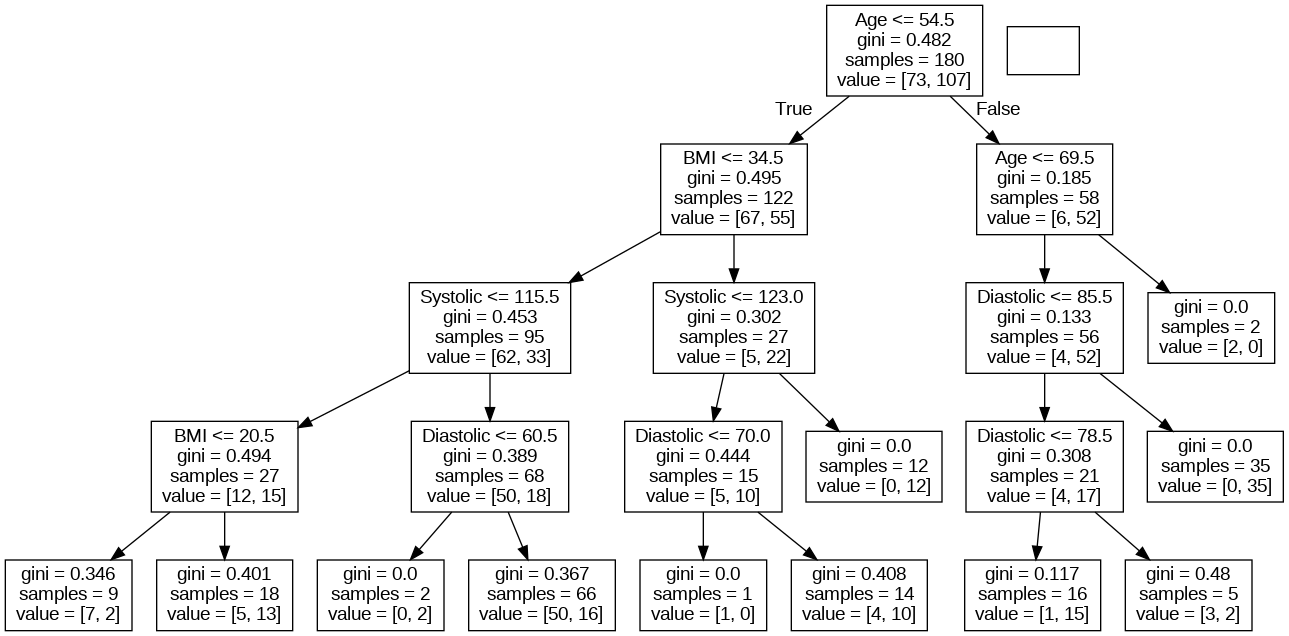

##**Análisis de Resultados**

El árbol de decisión nos permite identificar segmentos de pacientes con características similares y asociarlos a un resultado en específico. Por medio de los nodos puros de este modelo (los que tienen un índice Gini de 0), se pueden extraer las reglas del negocio de manera clara, ya que en estos nodos la clasificación es totalmente homogénea, para el caso de este modelo se tienen los siguientes nodos puros que se van a analziar:

* **Regla del negocio 1**: *si la edad es < 54, si el BMI es < 34, si la Systolic es > 115, si la Diastolic es < 60*, entonces la decisión que se va a presentar es que la persona tiene enfermedades cardiacas, porque existiría un 100% de probabilidad [0,2]

* **Regla del negocio 2:** *si la edad es < 54, si el MBI es > 34, si la Systolic es < 123, si la Diastolic es < 70*, entonces la decisión va a ser que la persona no presenta enfermedades cardíacas, porque tiene una probabilidad del 100% [1,0]

* **Regla del negocio 3**: *si la edad < 54, si el MBI es > 34, si la Systolic es > 123*, entonces la decisión va a ser que el paciente presenta enfermedades cardiacas, porque la probabilidad es del 100% [0,12]

* **Regla del negocio 4**: *si la edad > 54 y > 69*, entonces la decisión va a ser que el paciente no presenta enfermedades cardiacas, porque tiene una probabilidad del 100% [2,0]

* **Regla del negocio 5**: *si la edad > 54 y > 69, si la Diastolic > 85*, entonces la deicisión va a ser que el paciente presenta enfermedades cardiacas, porque tiene un 100% de probabilidad [0,35]


##**PARTE DE EXCEL**

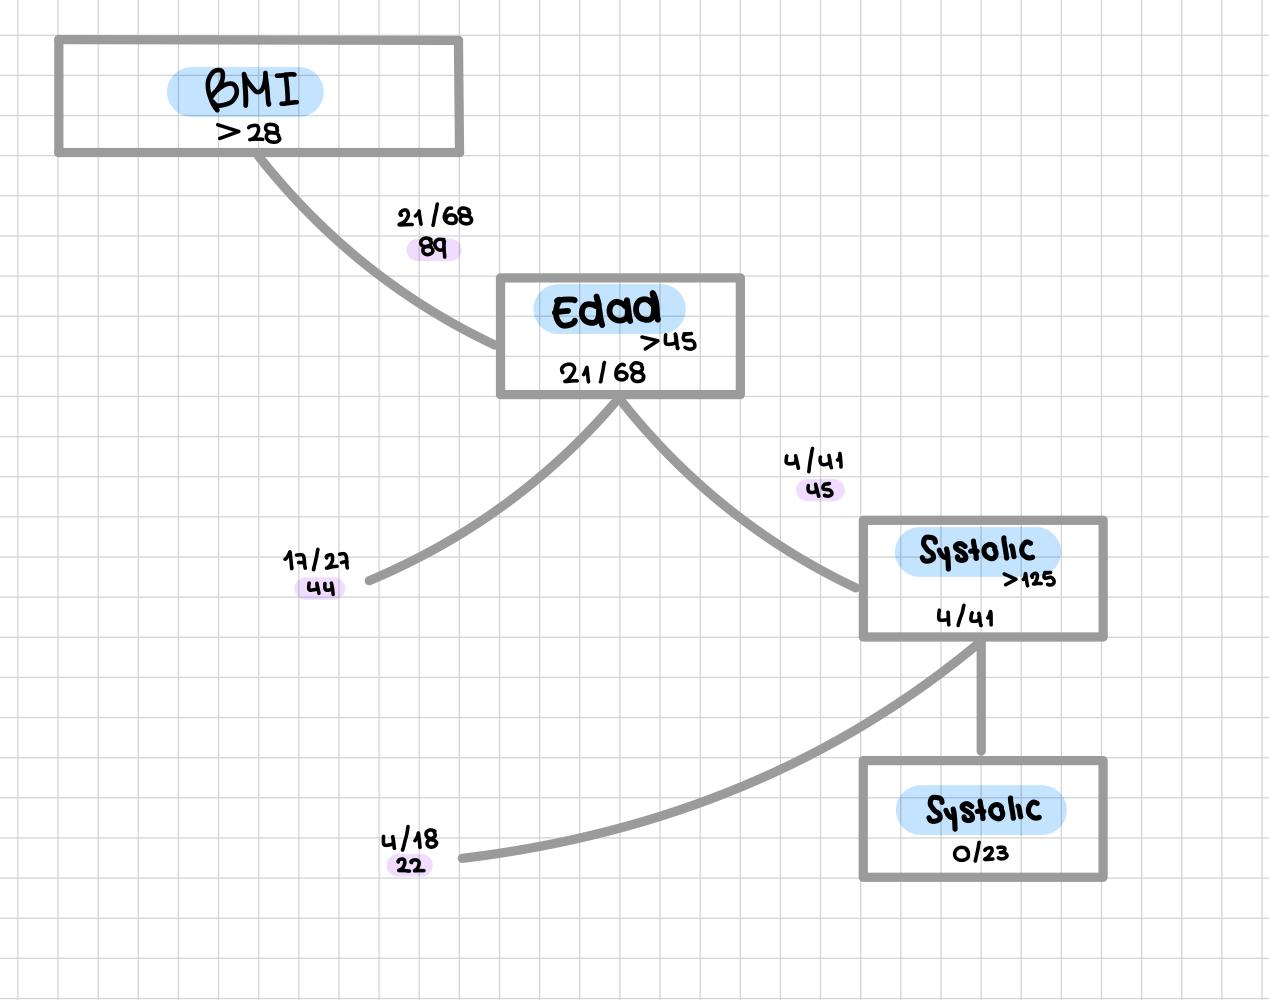

##**Análisis de Resultados**

El árbol de decisión que se realizó con los datos que se encontraron por medio del Excel para el mismo caso, muestran que la primera variable utilizada para dividir los datos es el BMI > 28, indicando que es la característica con mayor capacidad para diferenciar entre los pacientes según la variable objetivo. Seguido de esta, se utiliza la variable de la edad > 45 como el segundo criterio de segmentación y finalmente, se emplea la Systolic > 125 cpara terminar de completar la clasificación.

El árbol termina en un nodo puro, el cual es de la Systolic [0,23] entonces esto quiere decir que todos los pacientes presentan enfermedades cardiacas.
